# Feature and hyperparameter search

Notebook 2 found numeric gradient boosting to be the strongest model family, while contextual logistic regression remained easier to explain and export into a static browser application. This notebook carries both forward on identical chronological folds. It searches logistic features and regularization, retains the Notebook 2 boosted model as a performance control, and separately tests the granularity of course identity.


## 1. Load Notebook 1's canonical cache

Notebook 1 owns archive parsing, label construction, feature engineering, and deterministic sampling. This notebook reads the resulting per-session cache and performs no reconstruction.


In [1]:
from __future__ import annotations

import gc
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss, log_loss, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

cwd = Path.cwd().resolve()
PROJECT_ROOT = next((path for path in (cwd, *cwd.parents) if (path / 'README.md').exists() and (path / 'model').exists()), cwd)
CACHE_ROOT = PROJECT_ROOT / 'artifacts' / 'feature-search-cache'
ROWS_PER_SESSION = 300_000
CACHE_VERSION = 3
SESSION_ORDER = ['20229', '20235', '20239', '20245', '20249', '20255', '20259', '20265']
VALIDATION_SESSIONS = ['20239', '20249', '20259', '20265']
TRAIN_ROWS_PER_FOLD = 2_000_000
paths = {session: CACHE_ROOT / f'{session}-{ROWS_PER_SESSION}-v{CACHE_VERSION}.pkl' for session in SESSION_ORDER}
missing = [str(path) for path in paths.values() if not path.exists()]
if missing:
    raise FileNotFoundError('Run Notebook 1 to build the canonical cache. Missing: ' + ', '.join(missing))
session_samples = {session: pd.read_pickle(path) for session, path in paths.items()}
for frame in session_samples.values():
    parts = frame['course_code'].str.extract(r'^([A-Z]+)(\d)(\d{2})')
    frame['department'] = parts[0].fillna('UNKNOWN')
    frame['course_level'] = parts[1].fillna('UNKNOWN')
    frame['department_level'] = frame['department'] + frame['course_level']
    frame['course_number'] = (parts[0] + parts[1] + parts[2]).fillna('UNKNOWN')
print(f'Loaded {sum(map(len, session_samples.values())):,} cached modelling rows')


Loaded 2,379,974 cached modelling rows


## 2. Candidate feature sets and models

The main search compares raw and normalized logistic feature sets, regularization strengths, lecture identity, and the numeric gradient-boosting leader from Notebook 2. Every candidate uses identical cached training and validation rows within each chronological fold.

A second controlled search below isolates how course identity should be represented inside the logistic candidate.


In [2]:
RAW_NUMERIC = [
    'position', 'waitlist', 'capacity', 'days_to_deadline',
    'movement_3d', 'movement_7d', 'capacity_changed_7d',
]
RATIO_NUMERIC = [
    'position_to_capacity', 'waitlist_to_capacity', 'position_to_waitlist',
    'days_to_deadline', 'movement_velocity_7d', 'capacity_changed_7d',
]
ALL_NUMERIC = [
    'position_to_capacity', 'waitlist_to_capacity', 'days_to_deadline',
    'movement_3d', 'movement_7d', 'position', 'waitlist', 'capacity',
    'capacity_changed_7d', 'position_to_waitlist', 'days_squared',
    'log_waitlist', 'movement_velocity_7d',
]
CONTEXT_CATEGORICAL = ['course_code', 'campus', 'term']
LECTURE_CATEGORICAL = CONTEXT_CATEGORICAL + ['meeting', 'lecture_number']

def logistic_pipeline(numeric, categorical, C=1.0):
    features = ColumnTransformer([
        ('numeric', Pipeline([
            ('impute', SimpleImputer(strategy='constant', fill_value=0)),
            ('scale', StandardScaler()),
        ]), numeric),
        ('categorical', OneHotEncoder(handle_unknown='ignore', min_frequency=3), categorical),
    ])
    return Pipeline([
        ('features', features),
        ('model', LogisticRegression(C=C, solver='lbfgs', max_iter=300)),
    ])

def boosted_pipeline():
    return Pipeline([
        ('features', ColumnTransformer([
            ('numeric', SimpleImputer(strategy='median'), ALL_NUMERIC),
        ])),
        ('model', HistGradientBoostingClassifier(
            learning_rate=0.05,
            max_iter=200,
            max_leaf_nodes=15,
            l2_regularization=1.0,
            random_state=42,
        )),
    ])


CANDIDATES = {
    'boosted_numeric': boosted_pipeline,
    'raw_C0.3': lambda: logistic_pipeline(RAW_NUMERIC, CONTEXT_CATEGORICAL, C=0.3),
    'ratio_C0.3': lambda: logistic_pipeline(RATIO_NUMERIC, CONTEXT_CATEGORICAL, C=0.3),
    'context_C0.03': lambda: logistic_pipeline(ALL_NUMERIC, CONTEXT_CATEGORICAL, C=0.03),
    'context_C0.1': lambda: logistic_pipeline(ALL_NUMERIC, CONTEXT_CATEGORICAL, C=0.1),
    'context_C0.3': lambda: logistic_pipeline(ALL_NUMERIC, CONTEXT_CATEGORICAL, C=0.3),
    'context_C1': lambda: logistic_pipeline(ALL_NUMERIC, CONTEXT_CATEGORICAL, C=1.0),
    'context_C3': lambda: logistic_pipeline(ALL_NUMERIC, CONTEXT_CATEGORICAL, C=3.0),
    'lecture_C0.1': lambda: logistic_pipeline(ALL_NUMERIC, LECTURE_CATEGORICAL, C=0.1),
    'lecture_C0.3': lambda: logistic_pipeline(ALL_NUMERIC, LECTURE_CATEGORICAL, C=0.3),
    'lecture_C1': lambda: logistic_pipeline(ALL_NUMERIC, LECTURE_CATEGORICAL, C=1.0),
}
print(f'{len(CANDIDATES)} targeted candidates')

11 targeted candidates


## 3. Chronological search

Every candidate sees identical cached rows in each fold. Results are checkpointed after every fit, so an interrupted kernel can resume without losing completed work.

In [3]:
RESULTS_PATH = CACHE_ROOT / 'feature-search-canonical-v1.pkl'
results = pd.read_pickle(RESULTS_PATH).to_dict('records') if RESULTS_PATH.exists() else []
completed = {(row['validation_session'], row['candidate']) for row in results}

def weighted_ece(y, probability, weight, bins=10):
    edges = np.linspace(0, 1, bins + 1)
    groups = np.clip(np.digitize(probability, edges) - 1, 0, bins - 1)
    total = weight.sum()
    error = 0.0
    for group_number in range(bins):
        mask = groups == group_number
        if mask.any():
            observed = np.average(y[mask], weights=weight[mask])
            predicted = np.average(probability[mask], weights=weight[mask])
            error += weight[mask].sum() / total * abs(observed - predicted)
    return float(error)

for fold_number, valid_session in enumerate(VALIDATION_SESSIONS, start=1):
    valid_index = SESSION_ORDER.index(valid_session)
    train_sessions = SESSION_ORDER[:valid_index]
    train = pd.concat([session_samples[s] for s in train_sessions], ignore_index=True)
    model_train = train.sample(n=min(TRAIN_ROWS_PER_FOLD, len(train)), random_state=42)
    valid = session_samples[valid_session]
    print(f'Fold {valid_session}: {len(model_train):,} training rows; {len(valid):,} validation rows', flush=True)

    for candidate_number, (name, factory) in enumerate(CANDIDATES.items(), start=1):
        key = (valid_session, name)
        if key in completed:
            print(f'[{fold_number}/4, {candidate_number}/{len(CANDIDATES)}] {valid_session} {name}: cached', flush=True)
            continue
        started = time.perf_counter()
        print(f'[{fold_number}/4, {candidate_number}/{len(CANDIDATES)}] {valid_session} {name}: fitting', flush=True)
        numeric = RAW_NUMERIC if name.startswith('raw_') else RATIO_NUMERIC if name.startswith('ratio_') else ALL_NUMERIC
        categorical = (
            [] if name == 'boosted_numeric'
            else LECTURE_CATEGORICAL if name.startswith('lecture_')
            else CONTEXT_CATEGORICAL
        )
        feature_columns = numeric + categorical
        model = factory()
        model.fit(model_train[feature_columns], model_train['cleared'], model__sample_weight=model_train['model_weight'])
        probability = np.clip(model.predict_proba(valid[feature_columns])[:, 1], 1e-6, 1 - 1e-6)
        y = valid['cleared'].to_numpy()
        w = valid['model_weight'].to_numpy()
        results.append({
            'validation_session': valid_session,
            'candidate': name,
            'brier': brier_score_loss(y, probability, sample_weight=w),
            'log_loss': log_loss(y, probability, sample_weight=w, labels=[0, 1]),
            'ece_10': weighted_ece(y, probability, w),
            'roc_auc': roc_auc_score(y, probability, sample_weight=w),
            'seconds': time.perf_counter() - started,
        })
        pd.DataFrame(results).to_pickle(RESULTS_PATH)
        completed.add(key)
        print(f'  complete in {results[-1]["seconds"] / 60:.1f} min', flush=True)
        del model, probability
        gc.collect()
    del train, model_train
    gc.collect()

scores = pd.DataFrame(results).sort_values(['validation_session', 'brier']).reset_index(drop=True)
display(scores)

Fold 20239: 579,974 training rows; 300,000 validation rows
[1/4, 1/11] 20239 boosted_numeric: fitting
  complete in 0.0 min
[1/4, 2/11] 20239 raw_C0.3: fitting
  complete in 0.0 min
[1/4, 3/11] 20239 ratio_C0.3: fitting
  complete in 0.0 min
[1/4, 4/11] 20239 context_C0.03: fitting
  complete in 0.0 min
[1/4, 5/11] 20239 context_C0.1: fitting
  complete in 0.0 min
[1/4, 6/11] 20239 context_C0.3: fitting
  complete in 0.0 min
[1/4, 7/11] 20239 context_C1: fitting
  complete in 0.0 min
[1/4, 8/11] 20239 context_C3: fitting
  complete in 0.0 min
[1/4, 9/11] 20239 lecture_C0.1: fitting
  complete in 0.0 min
[1/4, 10/11] 20239 lecture_C0.3: fitting
  complete in 0.0 min
[1/4, 11/11] 20239 lecture_C1: fitting
  complete in 0.0 min
Fold 20249: 1,179,974 training rows; 300,000 validation rows
[2/4, 1/11] 20249 boosted_numeric: fitting
  complete in 0.1 min
[2/4, 2/11] 20249 raw_C0.3: fitting
  complete in 0.1 min
[2/4, 3/11] 20249 ratio_C0.3: fitting
  complete in 0.0 min
[2/4, 4/11] 20249 con

,validation_session,candidate,brier,log_loss,ece_10,roc_auc,seconds
0,20239,boosted_numeric,0.048963,0.165226,0.021644,0.949454,2.726172
1,20239,context_C3,0.063339,0.225100,0.030969,0.906878,2.728767
2,20239,lecture_C1,0.066576,0.231982,0.032448,0.899373,2.961012
3,20239,context_C1,0.066646,0.232571,0.034092,0.899470,2.189310
4,20239,context_C0.3,0.071213,0.234906,0.037833,0.896795,2.235772
5,20239,lecture_C0.3,0.071258,0.234971,0.036785,0.895776,2.572848
6,20239,ratio_C0.3,0.075667,0.249520,0.037455,0.876931,1.858284
7,20239,raw_C0.3,0.075803,0.254034,0.036702,0.868626,1.538580
8,20239,context_C0.1,0.076311,0.245659,0.044349,0.894600,1.754385
9,20239,lecture_C0.1,0.076563,0.246767,0.041040,0.891287,2.409584


## 4. Select a stable winner

Prefer the lowest mean Brier score, but reject a candidate that wins only one fold or materially worsens calibration. The main holdout remains `20259`.

,mean_brier,worst_brier,mean_log_loss,mean_ece,mean_auc,total_minutes
candidate,,,,,,
boosted_numeric,0.050848,0.056106,0.174061,0.025801,0.944467,0.399537
context_C3,0.063165,0.069600,0.211897,0.033606,0.922966,0.390688
lecture_C1,0.065812,0.073604,0.218044,0.033744,0.918430,0.452478
context_C1,0.065826,0.073719,0.218246,0.035151,0.918954,0.349385
lecture_C0.3,0.069896,0.079040,0.227107,0.037970,0.912959,0.390463
context_C0.3,0.069900,0.079167,0.227112,0.038722,0.913863,0.320840
ratio_C0.3,0.074164,0.084262,0.242414,0.038095,0.897001,0.236548
context_C0.1,0.074842,0.085689,0.239873,0.048385,0.909610,0.278059
lecture_C0.1,0.074928,0.085819,0.240345,0.046400,0.907411,0.356237


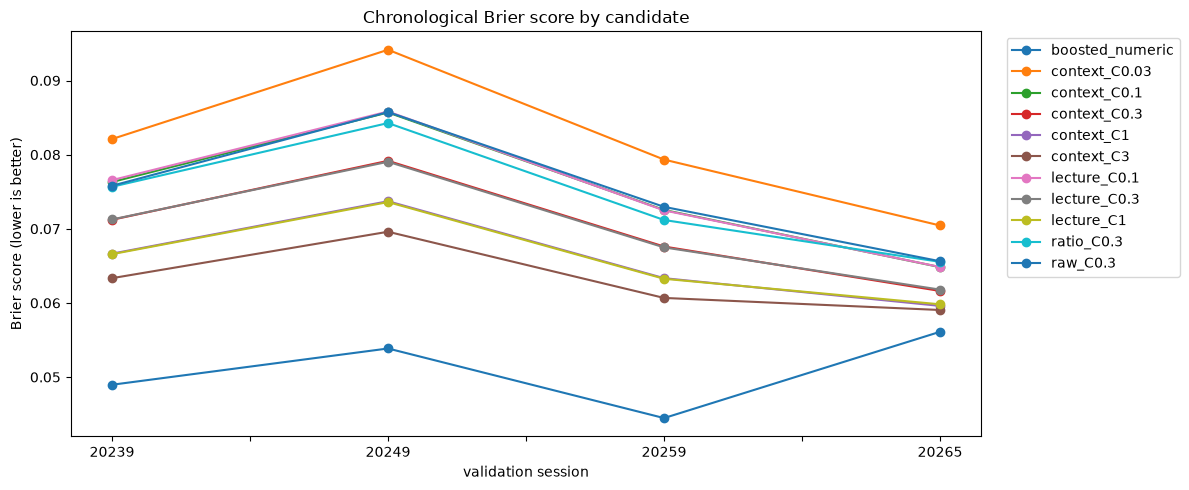

Provisional winner: boosted_numeric


In [4]:
summary = scores.groupby('candidate').agg(
    mean_brier=('brier', 'mean'),
    worst_brier=('brier', 'max'),
    mean_log_loss=('log_loss', 'mean'),
    mean_ece=('ece_10', 'mean'),
    mean_auc=('roc_auc', 'mean'),
    total_minutes=('seconds', lambda values: values.sum() / 60),
).sort_values(['mean_brier', 'mean_ece'])
display(summary)

pivot = scores.pivot(index='validation_session', columns='candidate', values='brier')
ax = pivot.plot(figsize=(12, 5), marker='o')
ax.set(title='Chronological Brier score by candidate', ylabel='Brier score (lower is better)', xlabel='validation session')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

winner = summary.index[0]
print('Provisional winner:', winner)

## 5. Course-identity granularity experiment

The existing model uses the complete code such as `CSC369H1F`. This controlled experiment keeps the numeric features, campus, term, regularization (`C=3`), folds, and cached rows fixed while changing only the representation of course identity:

- no course identity
- department only (`CSC`)
- year level only (`3`)
- department and level as separate features (`CSC` + `3`)
- department-level as one feature (`CSC3`)
- course number without campus or term (`CSC369`)
- the current complete code (`CSC369H1F`)


In [5]:
GRANULARITY = {
    'no_course': ['campus', 'term'],
    'department_only': ['department', 'campus', 'term'],
    'level_only': ['course_level', 'campus', 'term'],
    'department_plus_level': ['department', 'course_level', 'campus', 'term'],
    'department_level': ['department_level', 'campus', 'term'],
    'course_number': ['course_number', 'campus', 'term'],
    'full_course_code': ['course_code', 'campus', 'term'],
}
GRANULARITY_PATH = CACHE_ROOT / 'course-granularity-canonical-v1.pkl'
granularity_results = pd.read_pickle(GRANULARITY_PATH).to_dict('records') if GRANULARITY_PATH.exists() else []
granularity_completed = {(row['validation_session'], row['representation']) for row in granularity_results}

for fold_number, valid_session in enumerate(VALIDATION_SESSIONS, start=1):
    valid_index = SESSION_ORDER.index(valid_session)
    train = pd.concat([session_samples[s] for s in SESSION_ORDER[:valid_index]], ignore_index=True)
    model_train = train.sample(n=min(TRAIN_ROWS_PER_FOLD, len(train)), random_state=42)
    valid = session_samples[valid_session]
    for variant_number, (name, categorical) in enumerate(GRANULARITY.items(), start=1):
        key = (valid_session, name)
        if key in granularity_completed:
            print(f'[{fold_number}/4, {variant_number}/{len(GRANULARITY)}] {valid_session} {name}: cached', flush=True)
            continue
        started = time.perf_counter()
        print(f'[{fold_number}/4, {variant_number}/{len(GRANULARITY)}] {valid_session} {name}: fitting', flush=True)
        columns = ALL_NUMERIC + categorical
        model = logistic_pipeline(ALL_NUMERIC, categorical, C=3.0)
        model.fit(model_train[columns], model_train['cleared'], model__sample_weight=model_train['model_weight'])
        probability = np.clip(model.predict_proba(valid[columns])[:, 1], 1e-6, 1 - 1e-6)
        y = valid['cleared'].to_numpy()
        w = valid['model_weight'].to_numpy()
        granularity_results.append({
            'validation_session': valid_session,
            'representation': name,
            'brier': brier_score_loss(y, probability, sample_weight=w),
            'log_loss': log_loss(y, probability, sample_weight=w, labels=[0, 1]),
            'ece_10': weighted_ece(y, probability, w),
            'roc_auc': roc_auc_score(y, probability, sample_weight=w),
            'seconds': time.perf_counter() - started,
        })
        pd.DataFrame(granularity_results).to_pickle(GRANULARITY_PATH)
        granularity_completed.add(key)
        print(f'  complete in {granularity_results[-1]["seconds"] / 60:.1f} min', flush=True)
        del model, probability
        gc.collect()
    del train, model_train
    gc.collect()

granularity_scores = pd.DataFrame(granularity_results)
granularity_summary = granularity_scores.groupby('representation').agg(
    mean_brier=('brier','mean'), worst_brier=('brier','max'),
    mean_log_loss=('log_loss','mean'), mean_ece=('ece_10','mean'),
    mean_auc=('roc_auc','mean'), total_minutes=('seconds', lambda x: x.sum()/60),
).sort_values(['mean_brier','mean_ece'])
display(granularity_summary)
display(granularity_scores.pivot(index='validation_session', columns='representation', values='brier'))


[1/4, 1/7] 20239 no_course: fitting
  complete in 0.0 min
[1/4, 2/7] 20239 department_only: fitting
  complete in 0.0 min
[1/4, 3/7] 20239 level_only: fitting
  complete in 0.0 min
[1/4, 4/7] 20239 department_plus_level: fitting
  complete in 0.1 min
[1/4, 5/7] 20239 department_level: fitting
  complete in 0.0 min
[1/4, 6/7] 20239 course_number: fitting
  complete in 0.0 min
[1/4, 7/7] 20239 full_course_code: fitting
  complete in 0.0 min
[2/4, 1/7] 20249 no_course: fitting
  complete in 0.1 min
[2/4, 2/7] 20249 department_only: fitting
  complete in 0.1 min
[2/4, 3/7] 20249 level_only: fitting
  complete in 0.1 min
[2/4, 4/7] 20249 department_plus_level: fitting
  complete in 0.1 min
[2/4, 5/7] 20249 department_level: fitting
  complete in 0.1 min
[2/4, 6/7] 20249 course_number: fitting
  complete in 0.1 min
[2/4, 7/7] 20249 full_course_code: fitting
  complete in 0.1 min
[3/4, 1/7] 20259 no_course: fitting
  complete in 0.1 min
[3/4, 2/7] 20259 department_only: fitting
  complete in 

,mean_brier,worst_brier,mean_log_loss,mean_ece,mean_auc,total_minutes
representation,,,,,,
full_course_code,0.063165,0.069600,0.211897,0.033606,0.922966,0.389986
department_plus_level,0.063257,0.067902,0.212796,0.031831,0.921011,0.460549
course_number,0.063317,0.069568,0.212500,0.032825,0.921864,0.411832
department_only,0.063480,0.068952,0.213718,0.032639,0.920781,0.427860
level_only,0.063565,0.069777,0.213388,0.032775,0.921214,0.362702
department_level,0.063567,0.069477,0.213104,0.032419,0.921276,0.397717
no_course,0.063768,0.070911,0.214816,0.033396,0.920500,0.316345


representation,course_number,department_level,department_only,department_plus_level,full_course_code,level_only,no_course
validation_session,,,,,,,
20239,0.063549,0.063921,0.064084,0.063801,0.063339,0.063886,0.064391
20249,0.069568,0.069477,0.068952,0.067902,0.069600,0.069777,0.070911
20259,0.060523,0.061238,0.061750,0.061971,0.060675,0.061923,0.061138
20265,0.059629,0.059633,0.059135,0.059353,0.059046,0.058674,0.058631


## 6. Findings and decision

All candidates were trained on the same deterministic rows and evaluated on the same four chronological holdouts.

### Model and feature search

- `boosted_numeric` won **all four validation sessions** with **0.05085 mean Brier**, **0.02580 mean ECE**, and **0.94447 mean ROC AUC**.
- `context_C3` was the best logistic candidate with **0.06317 mean Brier**, **0.03361 mean ECE**, and **0.92297 mean ROC AUC**.
- Boosting reduced mean Brier error by **19.5%** relative to the best logistic candidate and also had better calibration and discrimination.
- Adding lecture identity did not help. The best lecture-aware candidate had **0.06581 mean Brier**, worse than `context_C3`.
- Weaker regularization consistently helped logistic regression. Among the tested values, `C=3` was best.

### Course-identity experiment

- Full course code produced the lowest mean Brier at **0.06317**, but the gain over no course identity at **0.06377** was small.
- Separate department and level features, such as `CSC` + `3`, were nearly tied at **0.06326 mean Brier** and had the best mean ECE and worst-fold Brier of the identity variants.
- Combining them into `CSC3` did not improve on keeping department and level separate.
- Exact course identity therefore adds some signal, but it is not the main source of predictive performance.

### Decision

`boosted_numeric` remains the primary model family. The performance gap is too large to select logistic regression solely for simpler browser export. Notebook 4 must evaluate calibration and failure slices for boosting while retaining `context_C3` as the interpretable comparison model. Browser export for the tree ensemble is an implementation task, not a reason to discard the statistical winner.